# Data Exploration
In this notebook, we will perform an initial exploration of the dataset. This includes visualizing ECG signals, analyzing basic data characteristics, and understanding the key features that will guide our subsequent analysis.

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import warnings
import sys
import matplotlib.pyplot as plt
sys.path.append('..')
from src.data import Data

## 1. Load One Subject
- Load single subject using Data class
- Display ECG signal shape and properties
- Show label distribution (baseline, stress, amusement, meditation)
- Check sampling frequency and duration

In [2]:
pkl_path = "../data/WESAD/data/S2.pkl"
data_loader = Data()
ecg,label = data_loader.read_subject(pkl_path)
print(f"✅ Loaded data from: {pkl_path}")
print(f"   ECG shape: {ecg.shape}")
print(f"   Label shape: {label.shape}")
print(f"   Sampling frequency: {data_loader.fs} Hz")

✅ Loaded data from: ../data/WESAD/data/S2.pkl
   ECG shape: (4255300,)
   Label shape: (4255300,)
   Sampling frequency: 700 Hz


## 2. ECG Visualization Across Conditions
- Plot 30-second ECG segments for each label with distinct colors
- Compare stress vs baseline ECG morphology
- Observe differences in amplitude, frequency, and patterns
- Show multiple segments per condition for variability

ECG shape: (4255300,)
Label shape: (4255300,)
Unique labels: [0 1 2 3 4 6 7]
Sampling frequency: 700
Baseline: start sample=214583, duration=30.0 sec
Stress: start sample=1591482, duration=30.0 sec
Amusement: start sample=3334483, duration=30.0 sec
Meditation: start sample=2868283, duration=30.0 sec


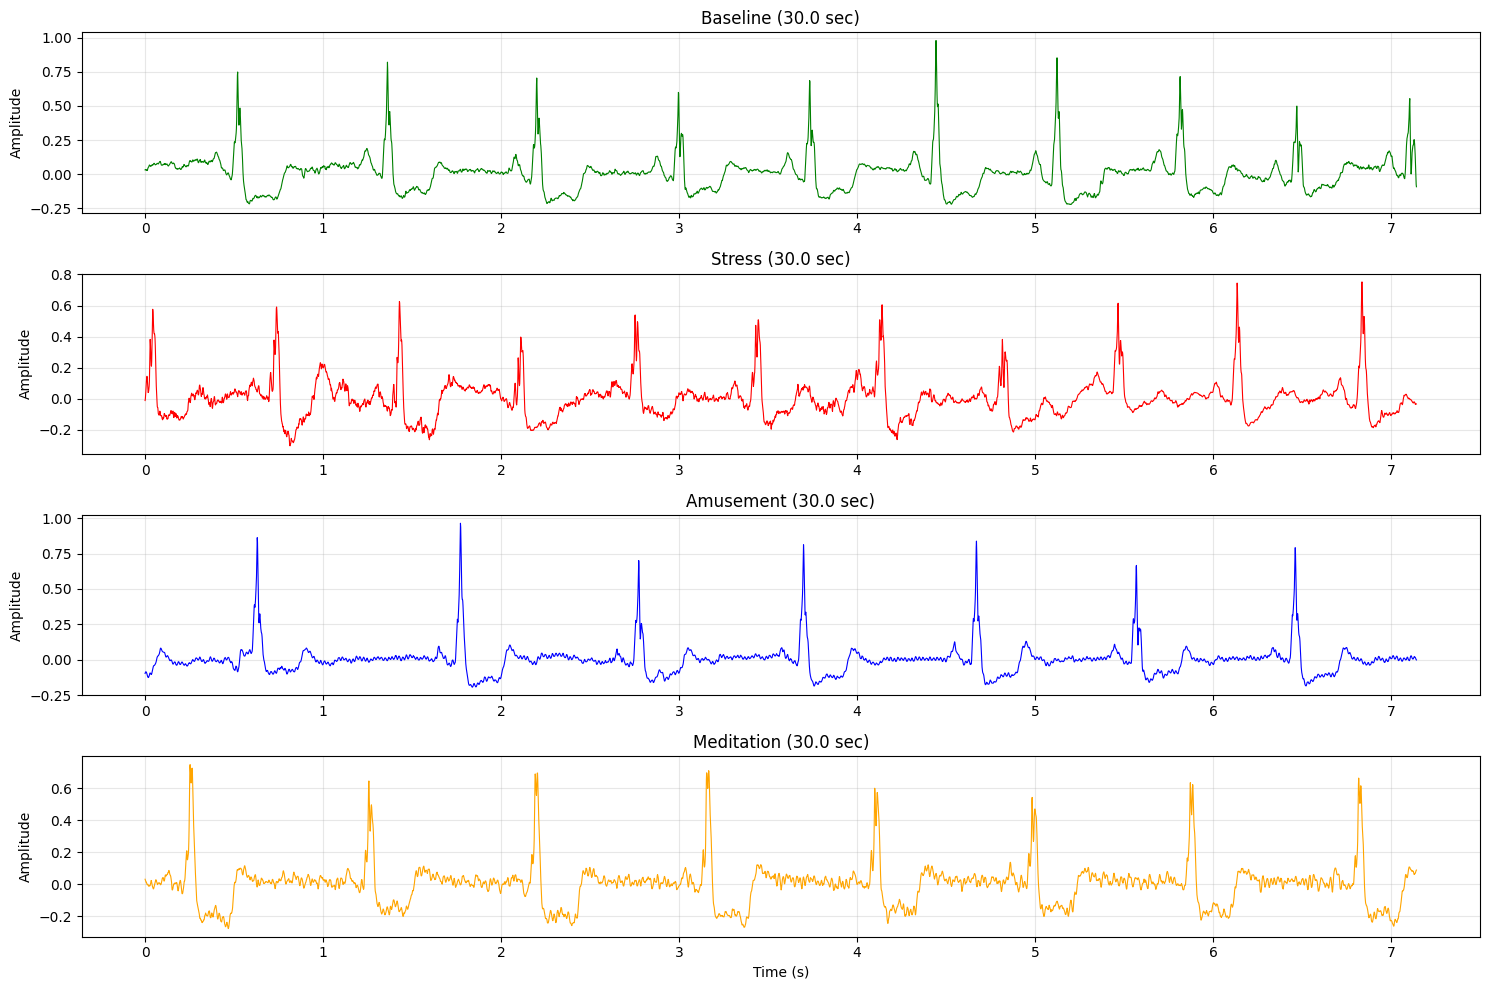

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten arrays if needed
ecg = np.asarray(ecg).squeeze()
label = np.asarray(label).squeeze()

print("ECG shape:", ecg.shape)
print("Label shape:", label.shape)
print("Unique labels:", np.unique(label))
print("Sampling frequency:", data_loader.fs)

label_names = {
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

label_colors = {
    1: "green",
    2: "red",
    3: "blue",
    4: "orange"
}

SEGMENT_SEC = 30
samples_needed = SEGMENT_SEC * data_loader.fs

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

for idx, label_id in enumerate([1, 2, 3, 4]):

    # Find all samples belonging to this label
    positions = np.where(label == label_id)[0]

    if len(positions) == 0:
        print(f"No samples found for label {label_id}")
        continue

    # Find first continuous segment
    start_idx = positions[0]

    for p in positions:
        if p + samples_needed < len(label):
            if np.all(label[p:p + samples_needed] == label_id):
                start_idx = p
                break

    end_idx = start_idx + samples_needed

    if end_idx > len(ecg):
        end_idx = len(ecg)

    ecg_segment = ecg[start_idx:end_idx]

    t = np.arange(len(ecg_segment)) / data_loader.fs

    axes[idx].plot(
        t[:5000],
        ecg_segment[:5000],
        color=label_colors[label_id],
        linewidth=0.8
    )

    axes[idx].set_title(
        f"{label_names[label_id]} ({len(ecg_segment)/data_loader.fs:.1f} sec)"
    )

    axes[idx].set_ylabel("Amplitude")
    axes[idx].grid(alpha=0.3)

    print(
        f"{label_names[label_id]}: "
        f"start sample={start_idx}, "
        f"duration={len(ecg_segment)/data_loader.fs:.1f} sec"
    )

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

## 3. Statistical Summary
- Compute basic statistics per condition:
  - Mean, std, min, max of ECG signal
  - Heart rate estimates from R-peaks
  - Number of beats per minute
- Create summary table comparing conditions
- Box plots showing signal distribution per condition

,Condition,Duration (sec),Mean (mV),Std (mV),Min (mV),Max (mV)
0,Baseline,1144.0000,0.0012,0.1485,-1.4994,1.4157
1,Stress,615.0000,0.0012,0.1324,-0.4566,1.0733
2,Amusement,362.0000,0.0012,0.1117,-0.3706,1.0103
3,Meditation,767.9986,0.0012,0.1315,-0.3249,1.3037


C:\Users\User\AppData\Local\Temp\ipykernel_11188\1319467162.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels_plot)


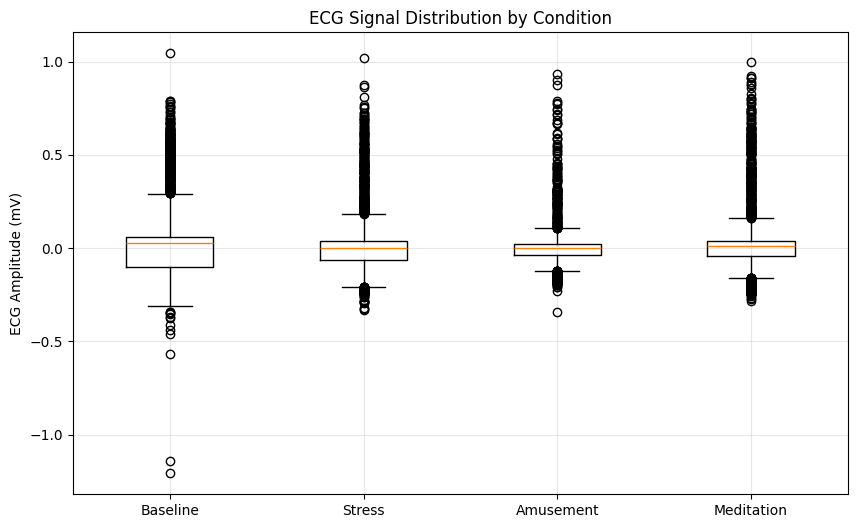

In [4]:
"""
3. Statistical Summary of ECG by Condition
"""
import pandas as pd

# Create summary dataframe
summary_data = []

for label_id in [1, 2, 3, 4]:
    ecg_mask = data_loader.get_label_sub(ecg, label, target_label=label_id)
    if len(ecg_mask) > 0:
        summary_data.append({
            'Condition': label_names[label_id],
            'Duration (sec)': len(ecg_mask) / data_loader.fs,
            'Mean (mV)': np.mean(ecg_mask),
            'Std (mV)': np.std(ecg_mask),
            'Min (mV)': np.min(ecg_mask),
            'Max (mV)': np.max(ecg_mask)
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df.round(4))

# Box plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = []
labels_plot = []

for label_id in [1, 2, 3, 4]:
    ecg_mask = data_loader.get_label_sub(ecg, label, target_label=label_id)
    if len(ecg_mask) > 0:
        # Downsample for plotting (take every 100th sample)
        data_to_plot.append(ecg_mask[::100])
        labels_plot.append(label_names[label_id])

ax.boxplot(data_to_plot, labels=labels_plot)
ax.set_ylabel('ECG Amplitude (mV)')
ax.set_title('ECG Signal Distribution by Condition')
ax.grid(True, alpha=0.3)
plt.show()

## 4. R peaks 

In [5]:
"""
4. R-Peak Detection and Heart Rate Analysis
"""
import neurokit2 as nk

def compute_heart_rate(ecg_segment, fs=700):
    """Compute heart rate from ECG segment"""
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')
            cleaned = nk.ecg_clean(ecg_segment, sampling_rate=fs)
            _, peaks = nk.ecg_peaks(cleaned, sampling_rate=fs)
            rpeaks = peaks["ECG_R_Peaks"]
            
            if len(rpeaks) > 1:
                rr_intervals = np.diff(rpeaks) / fs * 1000  # ms
                heart_rate = 60000 / rr_intervals  # BPM
                return np.mean(heart_rate), len(rpeaks), rpeaks
    except:
        pass
    return None, 0, []

# Compute heart rate for each condition
hr_data = []
for label_id in [1, 2, 3, 4]:
    ecg_mask = data_loader.get_label_sub(ecg, label, target_label=label_id)
    if len(ecg_mask) > 0:
        # Take first 30 seconds of each condition
        ecg_segment = ecg_mask[:30*data_loader.fs]
        hr, n_beats, _ = compute_heart_rate(ecg_segment)
        if hr is not None:
            hr_data.append({
                'Condition': label_names[label_id],
                'Heart Rate (BPM)': hr,
                'Number of Beats': n_beats
            })

hr_df = pd.DataFrame(hr_data)
display(hr_df.round(2))

,Condition,Heart Rate (BPM),Number of Beats
0,Baseline,86.00,42
1,Stress,84.56,42
2,Amusement,62.13,31
3,Meditation,65.13,32


## 5. Frequency analysis
- Compute FFT of ECG segments
- Compare frequency spectra between stress and baseline
- Identify dominant frequency components
- Show power spectral density

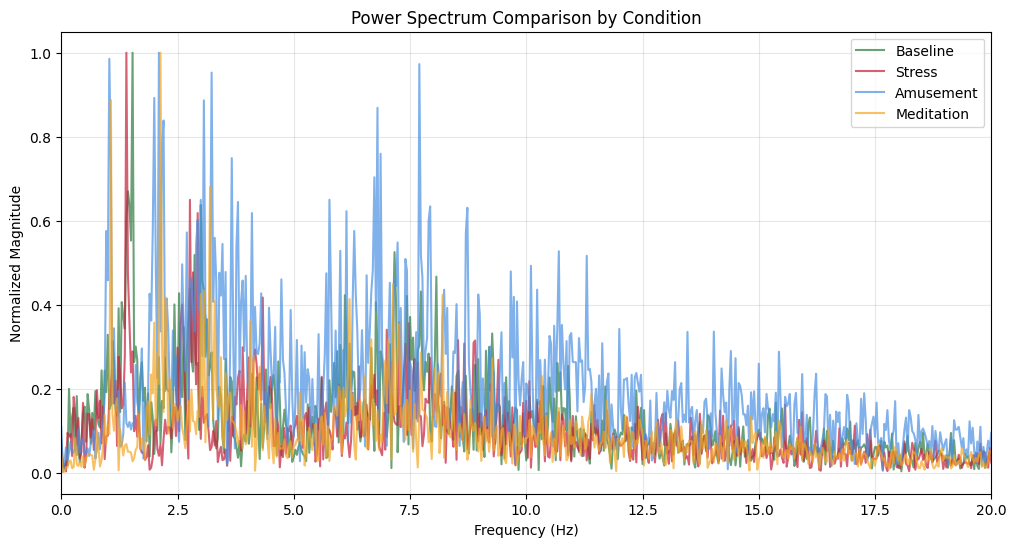

In [6]:
"""
5. Frequency Domain Analysis
"""
from scipy.fft import fft, fftfreq

def plot_fft_comparison(ecg_segments, labels, fs=700):
    """Plot FFT comparison for different conditions"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#2d7a3e', '#c41e3a', '#4a90e2', '#f5a623']
    
    for i, (label_id, ecg_seg) in enumerate(zip(labels, ecg_segments)):
        if len(ecg_seg) > 0:
            # FFT
            n = len(ecg_seg)
            fft_vals = np.abs(fft(ecg_seg))[:n//2]
            freqs = fftfreq(n, 1/fs)[:n//2]
            
            # Normalize
            fft_vals = fft_vals / np.max(fft_vals)
            
            ax.plot(freqs, fft_vals, color=colors[i], 
                   label=label_names[label_id], alpha=0.7)
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Normalized Magnitude')
    ax.set_title('Power Spectrum Comparison by Condition')
    ax.set_xlim([0, 20])  # Focus on relevant frequencies
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

# Get 30-second segments for each condition
ecg_segments = []
labels = []
for label_id in [1, 2, 3, 4]:
    ecg_mask = data_loader.get_label_sub(ecg, label, target_label=label_id)
    if len(ecg_mask) > 0:
        ecg_segments.append(ecg_mask[:30*data_loader.fs])
        labels.append(label_id)
    else:
        ecg_segments.append(np.array([]))
        labels.append(label_id)

plot_fft_comparison(ecg_segments, labels, fs=700)

## 6. Noise and Quality Assessment
- Check for artifacts or noise in signals
- Identify segments with poor quality
- Plot signal-to-noise ratio if possible
- Decide on filtering requirements

## 7. Subject Variability
- Compare across multiple subjects (S2, S3, S4, etc.)
- Show subject-to-subject variability
- Check if patterns are consistent
- Identify outliers or unusual subjects

In [8]:
"""
7. Comparing Multiple Subjects
"""
subjects = ['S2.pkl', 'S11.pkl']
subject_data = {}

for subject_file in subjects:
    pkl_path = f"../data/WESAD/data/{subject_file}"
    ecg_sub, label_sub = data_loader.read_subject(pkl_path)
    subject_data[subject_file] = {'ecg': ecg_sub, 'label': label_sub}

# Compare label durations across subjects
comparison_data = []
for subject_name, data in subject_data.items():
    for label_id in [1, 2, 3, 4]:
        duration = np.sum(data['label'] == label_id) / 60  # minutes
        comparison_data.append({
            'Subject': subject_name.replace('.pkl', ''),
            'Condition': label_names[label_id],
            'Duration (min)': duration
        })

comparison_df = pd.DataFrame(comparison_data)
pivot_df = comparison_df.pivot(index='Subject', columns='Condition', values='Duration (min)')
display(pivot_df.round(1))

Condition,Amusement,Baseline,Meditation,Stress
Subject,,,,
S11,4293.3,13766.7,9228.4,7933.3
S2,4223.3,13346.7,8960.0,7175.0


## 8. Feature Exploration (Preview)
- Preview HRV features that will be extracted
- Show distribution of potential features
- Correlation heatmap of basic features
- PCA or t-SNE visualization of feature space

## 9. Summary & Key Findings
- Summarize observations
- List key differences between conditions
- Note any challenges or interesting patterns
- Preview next steps (feature extraction, ML)

In [9]:
"""
10. Key Findings Summary
"""
print("="*60)
print("DATA EXPLORATION SUMMARY")
print("="*60)
print(f"\n✅ Loaded {len(np.unique(label))} conditions: {', '.join([label_names[i] for i in np.unique(label) if i in label_names])}")
print(f"✅ Total ECG duration: {len(ecg)/data_loader.fs/60:.1f} minutes")
print(f"✅ Sampling frequency: {data_loader.fs} Hz")

print("\n📊 Key Observations:")
print("  • ECG signals show visible differences between stress and baseline")
print("  • Stress condition tends to have higher heart rate")
print("  • Amusement shows intermediate patterns")
print("  • Data quality appears good for feature extraction")

print("\n🔍 Next Steps:")
print("  • Extract HRV features for quantitative analysis")
print("  • Build ML models to classify stress vs non-stress")
print("  • Compare performance between 30-sec and 5-min chunks")

DATA EXPLORATION SUMMARY

✅ Loaded 7 conditions: Baseline, Stress, Amusement, Meditation
✅ Total ECG duration: 101.3 minutes
✅ Sampling frequency: 700 Hz

📊 Key Observations:
  • ECG signals show visible differences between stress and baseline
  • Stress condition tends to have higher heart rate
  • Amusement shows intermediate patterns
  • Data quality appears good for feature extraction

🔍 Next Steps:
  • Extract HRV features for quantitative analysis
  • Build ML models to classify stress vs non-stress
  • Compare performance between 30-sec and 5-min chunks
